In [28]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import copy
import sys
sys.path.append('../survey_design/')
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
mag_max_eval_range=[[19, 21]]
max_mag_bright= [20.5]
config_bright_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(_surveys.config_survey_bright, max_mag=max_mag_bright, mag_max_eval_range=mag_max_eval_range) 

mag_max_eval_range=[[20, 21.8], [20, 22.5], [22,25]]
max_mag_grey= [21.3, 24, 25]
config_grey_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(_surveys.config_survey_grey, max_mag=max_mag_grey, mag_max_eval_range=mag_max_eval_range)     

mag_max_eval_range=[[18, 22]]
max_mag_grey_magmax= [20.5]
config_grey_magmax_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(_surveys.config_survey_grey_magmax, max_mag=max_mag_grey_magmax, mag_max_eval_range=mag_max_eval_range)     


mag_max_eval_range=[[23, 24.5], [24.2, 26], [24.2, 26], [24.2, 26]]
max_mag_dark= [24.5, 25, 25.5, 25.5]
config_dark_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(_surveys.config_survey_dark, max_mag=max_mag_dark, mag_max_eval_range=mag_max_eval_range)   

 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 
 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 
 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 
 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 


In [54]:
def plot_surface_density(config_survey_update, max_mag = None):

    for j, tracer in enumerate(config_survey_update['tracers']):

        plt.fill_between( config_survey_update[tracer + '_' + 'mag_centers'], 
                  config_survey_update[tracer + '_' + 'target_density'], 0*config_survey_update[tracer + '_' + 'target_density'], ls=f'-', 
                  color = config_survey_update['color'][j],  alpha=0.4)

        plt.plot( config_survey_update[tracer + '_' + 'mag_centers'], 
                  config_survey_update[tracer + '_' + 'target_density'],  ls=f'-', lw=2,
                  color = config_survey_update['color'][j], label = tracer + f' ({config_survey_update["limiting_mag_band"][j]}-band)',)

    plt.ylabel(r'Density of targets (deg$^{-2}$)', fontsize=14)
    plt.xlabel(r'$m < m_{\rm max}$', fontsize=14)
    plt.yscale('log')
    plt.ylim(300, 10e4)
    plt.xlim(19, 25.8)
    plt.tick_params(axis='both', labelsize=14)
    plt.legend(ncols=2, loc='upper right')

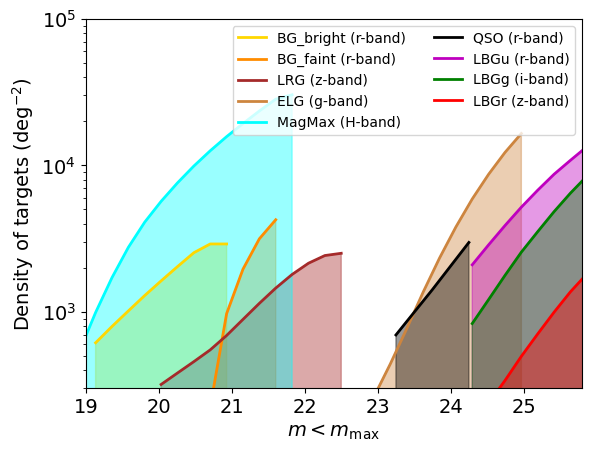

In [55]:
plot_surface_density(config_bright_update, max_mag = [max_mag_bright])
plot_surface_density(config_grey_update, max_mag = [max_mag_grey])
plot_surface_density(config_grey_magmax_update, max_mag = [max_mag_grey])
plot_surface_density(config_dark_update, max_mag = [max_mag_dark])

In [58]:
def plot_redshift_distrib(config_survey_update, max_mag = None):

    for j, tracer in enumerate(config_survey_update['tracers']):

        index = np.argmin(abs(config_survey_update[tracer + '_' + 'mag_centers'] - max_mag[j]))
        n = config_survey_update[tracer + '_' + 'spec_density'][index]
        z, x = config_survey_update[tracer + '_' + 'redshift_centers'], config_survey_update[tracer + '_' + 'spec_redshift_density'][index]
        print(n)
        #plt.fill_between(z ,x, 0*x/np.trapz(x,z), ls=f'-',  color = config_survey_update['color'][j], alpha=0.4)
        plt.plot(z ,n*x/np.trapz(x,z), f'-',  color = config_survey_update['color'][j],  label = tracer  + f' ({config_survey_update["limiting_mag_band"][j]} < {max_mag[j]:.1f})')

        #z, x = config_survey_update[tracer + '_' + 'redshift_centers'], config_survey_update[tracer + '_' + 'target_redshift_density'][index]
        #plt.step(z ,x, f'--',  color = config_survey_update['color'][j], where='mid',)

    plt.ylabel(r'$n_{\rm gal}\times dp(z)/dz$', fontsize=14)
    plt.xlabel('(photometric) redshift', fontsize=14)
    plt.tick_params(axis='both', labelsize=14)
    plt.legend(ncols=2)
    plt.xlim(0.00, 2)
    #plt.ylim(0, 4)

2505.165754923413
2964.042669584245
2122.163566739606
11739.813460612164
9789.214285714286
1745.1341474550134
2815.970562114275
1972.7493933176952
334.045938598147


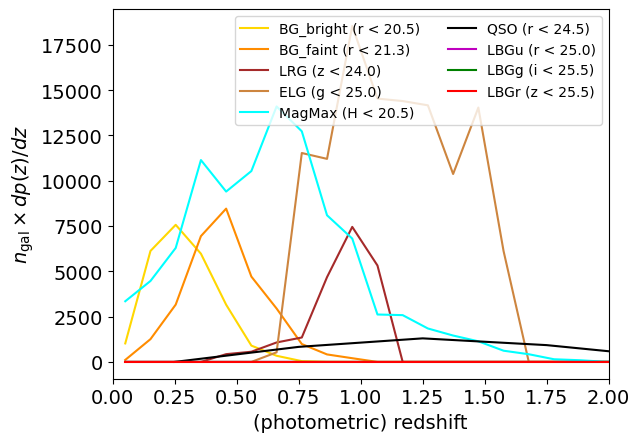

In [59]:
for i, c in enumerate([config_bright_update , config_grey_update, config_grey_magmax_update, config_dark_update]):
    #plt.figure(figsize=(20,3))
    plot_redshift_distrib(c, max_mag = [max_mag_bright, max_mag_grey, max_mag_grey_magmax, max_mag_dark][i])

In [60]:
def plot_tota_eff_lbg(config_survey_update):
    for j, tracer in enumerate(config_survey_update['tracers']):
        if tracer == 'QSO': continue
        if tracer == 'LBGu': z_lim = 2
        if tracer == 'LBGg': z_lim = 3
        if tracer == 'LBGr': z_lim = 4

        eff_ts_list = []
        for m in config_survey_update[tracer + '_' + 'mag_centers']:
            index = np.argmin(abs(config_survey_update[tracer + '_' + 'mag_centers'] - m))
            z_axis = config_survey_update[tracer + '_' + 'redshift_centers']
            nz = config_survey_update[tracer + '_' + 'target_redshift_density'][index]
            eff_ts_list.append(np.sum(nz[z_axis > z_lim])/np.sum(nz))

        config_survey_update[tracer + '_' + 'target_redshift_density']

        plt.plot(config_survey_update[tracer + '_' + 'mag_centers'], eff_ts_list, color = config_survey_update['color'][j],  lw=2,
                  label = 'target selection-only efficiency '+tracer + f' ({config_survey_update["limiting_mag_band"][j]}-band)',ls='--')
        plt.plot( config_survey_update[tracer + '_' + 'mag_centers'], 
                 config_survey_update[tracer + '_' + 'spec_density']/config_survey_update[tracer + '_' + 'target_density'], f'',
                  color = config_survey_update['color'][j], lw=2)
        
    plt.ylabel(r'Efficiency', fontsize=12)
    plt.xlabel('maximum magnitude', fontsize=12)
    plt.tick_params(axis='both', labelsize=14)
    plt.plot([], [], label='Total efficiency')
    plt.legend(fontsize=12)
    plt.ylim(0, 1)

    return None

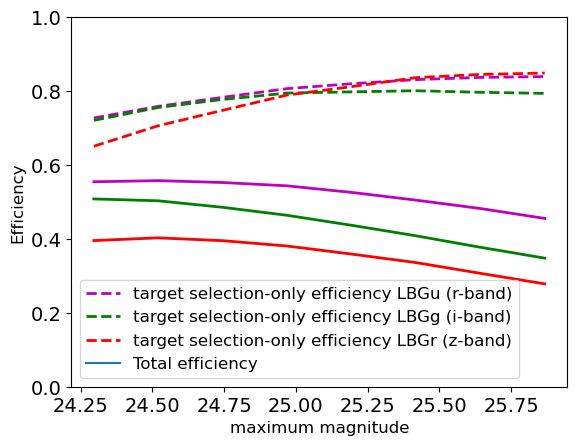

In [192]:
plot_tota_eff_lbg(config_dark_update)

(0.0, 1.01)

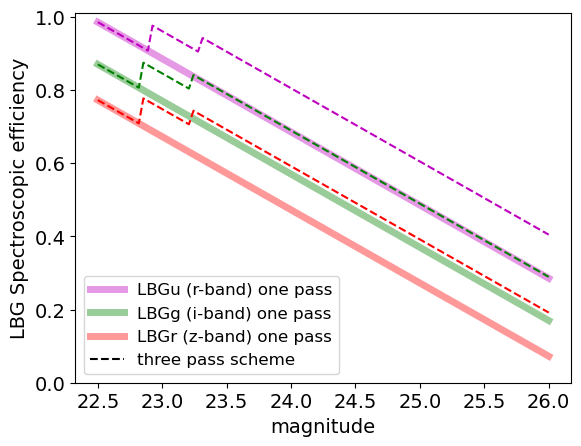

In [193]:
mag = np.linspace(22.5, 26, 100)

plt.plot(mag, _tracer_spectroscopic_efficiency.E_wst_lbg_dropout(3, mag, dropout_band = 'u', reference = 'desi', number_of_passes = 1), lw=5, color='m', alpha=0.4,
        label = 'LBGu (r-band) one pass')
plt.plot(mag, _tracer_spectroscopic_efficiency.E_wst_lbg_dropout(4, mag, dropout_band = 'g', reference = 'desi', number_of_passes = 1), lw=5, color='g', alpha=0.4,
        label = 'LBGg (i-band) one pass')
plt.plot(mag, _tracer_spectroscopic_efficiency.E_wst_lbg_dropout(5, mag, dropout_band = 'r', reference = 'desi', number_of_passes = 1), lw=5, color='r', alpha=0.4,
        label = 'LBGr (z-band) one pass')

plt.plot(mag, _tracer_spectroscopic_efficiency.E_wst_lbg_dropout_piecewise(3, mag, p_min=0.9, plateau=1, dropout_band = 'u', return_magnitudes=False), color='m', ls='--')
plt.plot(mag, _tracer_spectroscopic_efficiency.E_wst_lbg_dropout_piecewise(4, mag, p_min=0.8, plateau=1, dropout_band = 'g', return_magnitudes=False), color='g', ls='--')
plt.plot(mag, _tracer_spectroscopic_efficiency.E_wst_lbg_dropout_piecewise(5, mag, p_min=0.7, plateau=1, dropout_band = 'r', return_magnitudes=False), color='r', ls='--')
#def E_wst_lbg_dropout_piecewise(redshift, mag, p_min=0.7, plateau=0.8, dropout_band = 'u', return_magnitudes=False):
plt.ylabel(r'LBG Spectroscopic efficiency', fontsize=14)
plt.xlabel('magnitude', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.plot([], [], '--k',  label = 'three pass scheme')
plt.legend(fontsize=12)
plt.ylim(0, 1.01)